In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Total columns display
pd.set_option('display.max_columns', None) 

In [3]:
df=pd.read_csv("IPL IMB381IPL2013.csv")
df.head()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,0,0.0,0,0,0,0.00,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,185,37.6,0,0,0,0.00,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,288,32.9,0,167,39,18.56,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,51,36.8,0,58,11,5.80,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,0,0.0,0,1317,71,32.93,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000


# Dataset Description
## Description :- 
- AGE : Age of the Player classified into Three Categories.
- RUNS_s : Number of runs scored by Palyer.
- RUNS-c : Number of runs conceded by a palyer.
- HS : Highest Score by a batsman in IPL.
- AVE-B :Average runs scored by a batsman in IPL.
- AVE-BL : Bowling avarge (Number of runs conceted / number of wickets taken)in IPL.
- SR- B : Batting strike rate
- SR-BL : Bowling Strike rate 
- SIXERS : Number of six scored by a player in IPL.
- WKTS : Number of Wikets Taken by a palyer in IPL.
-  ECON-Economy rate of a bowler (number of runs conceded by the bowler per over) in IPL.
  -  CAPTAINCY EXP-Captained either a T20 team or a national team.
   - ODI-SR-B-Batting strike rate in One-Day Internationals.
   - ODI-SR-BL-Bowling strike rate in One-Day Internationals.
   - ODI-RUNS-S-Runs scored in One-Day Internationals.
   - ODI-WKTS-Wickets taken in One-Day Internationals.
   - T-RUNS-S-Runs scored in Test matches.
   - T-WKTS-Wickets taken in Test matches.
   - PLAYER -SKILL-Player's primary skill(batsman,bowler,or allrounder)
   - COUNTERY-country of origin of the player


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

In [5]:
df.describe()

,Sl.NO.,AGE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,1.300000e+02,1.300000e+02
mean,65.500000,2.092308,2166.715385,66.530769,2508.738462,71.164385,76.076923,34.033846,0.315385,514.246154,47.430769,18.719308,111.053462,17.692308,475.523077,17.169231,23.110231,6.204462,17.382615,2009.092308,1.922308e+05,5.212231e+05
std,37.671829,0.576627,3305.646757,142.676855,3582.205625,25.898440,111.205070,26.751749,0.466466,615.226335,36.403624,11.094224,35.928907,23.828146,558.314049,21.816763,20.802057,4.941531,15.273422,1.377821,1.530973e+05,4.068074e+05
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,2.000000e+04,2.000000e+04
25%,33.250000,2.000000,25.500000,0.000000,73.250000,65.650000,0.000000,0.000000,0.000000,39.000000,16.000000,9.825000,98.237500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,1.000000e+05,2.250000e+05
50%,65.500000,2.000000,542.500000,7.000000,835.000000,78.225000,18.500000,36.600000,0.000000,172.000000,35.500000,18.635000,118.510000,6.000000,297.000000,8.500000,24.785000,7.380000,19.935000,2008.000000,2.000000e+05,4.375000e+05
75%,97.750000,2.000000,3002.250000,47.500000,3523.500000,86.790000,106.000000,45.325000,1.000000,925.250000,73.750000,27.872500,129.102500,29.750000,689.250000,23.750000,35.580000,8.247500,26.212500,2011.000000,2.250000e+05,7.000000e+05
max,130.000000,3.000000,15470.000000,800.000000,18426.000000,116.660000,534.000000,150.000000,1.000000,2254.000000,158.000000,50.110000,235.490000,129.000000,1975.000000,83.000000,126.300000,38.110000,100.200000,2011.000000,1.350000e+06,1.800000e+06


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl.NO.,130.0,65.500000,37.671829,1.0,33.2500,65.500,97.7500,130.00
AGE,130.0,2.092308,0.576627,1.0,2.0000,2.000,2.0000,3.00
T-RUNS,130.0,2166.715385,3305.646757,0.0,25.5000,542.500,3002.2500,15470.00
T-WKTS,130.0,66.530769,142.676855,0.0,0.0000,7.000,47.5000,800.00
ODI-RUNS-S,130.0,2508.738462,3582.205625,0.0,73.2500,835.000,3523.5000,18426.00
ODI-SR-B,130.0,71.164385,25.898440,0.0,65.6500,78.225,86.7900,116.66
ODI-WKTS,130.0,76.076923,111.205070,0.0,0.0000,18.500,106.0000,534.00
ODI-SR-BL,130.0,34.033846,26.751749,0.0,0.0000,36.600,45.3250,150.00
CAPTAINCY EXP,130.0,0.315385,0.466466,0.0,0.0000,0.000,1.0000,1.00
RUNS-S,130.0,514.246154,615.226335,0.0,39.0000,172.000,925.2500,2254.00


In [7]:
df.isna()

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
126,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
127,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
128,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isna().sum()

Sl.NO.           0
PLAYER NAME      0
AGE              0
COUNTRY          0
TEAM             0
PLAYING ROLE     0
T-RUNS           0
T-WKTS           0
ODI-RUNS-S       0
ODI-SR-B         0
ODI-WKTS         0
ODI-SR-BL        0
CAPTAINCY EXP    0
RUNS-S           0
HS               0
AVE              0
SR-B             0
SIXERS           0
RUNS-C           0
WKTS             0
AVE-BL           0
ECON             0
SR-BL            0
AUCTION YEAR     0
BASE PRICE       0
SOLD PRICE       0
dtype: int64

In [9]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

<Axes: xlabel='COUNTRY', ylabel='count'>

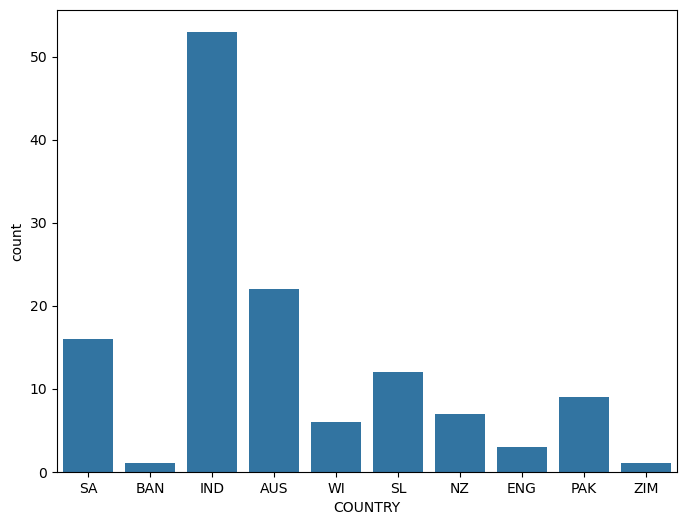

In [10]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='COUNTRY')

- From the graph, we can observe that India has the highest number of players in the dataset.
- Australia has the second-highest number of players.
- South Africa and Sri Lanka then next Pakistan players.
- West Indies and New Zealand.
- then lats England and Zimbabwe.



<Axes: xlabel='PLAYING ROLE', ylabel='count'>

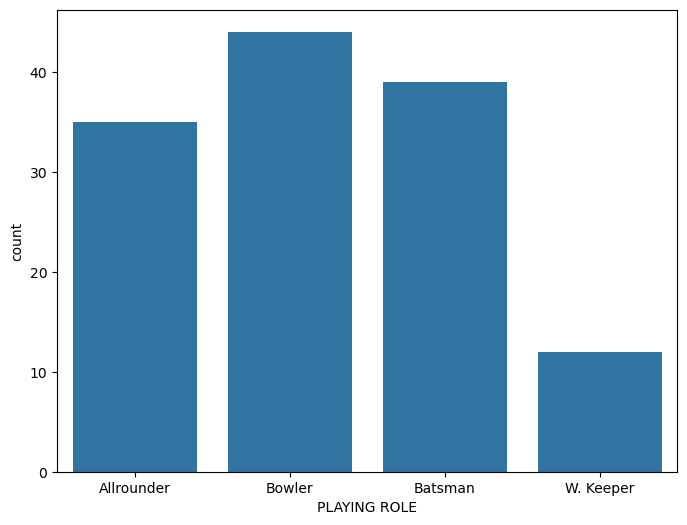

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='PLAYING ROLE')

- The Highest Playing role in IPl Bowler
- The graph shows that the highest number of players are Bowlers, followed by Batsmen. and Wicket-Keepers have the lowest count.

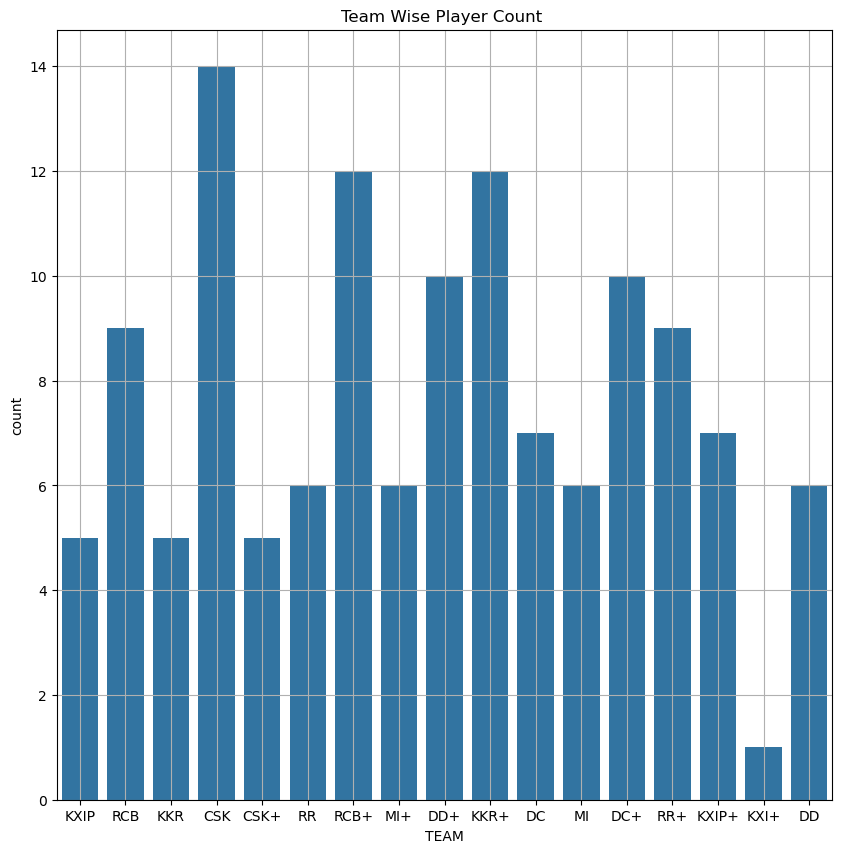

In [12]:
plt.figure(figsize=(10,10))

sns.countplot(data=df,x='TEAM')
plt.title("Team Wise Player Count ")
plt.grid()
plt.show()


- In this plot show then first Higest csk team,
- And lowest team count is KXI team.

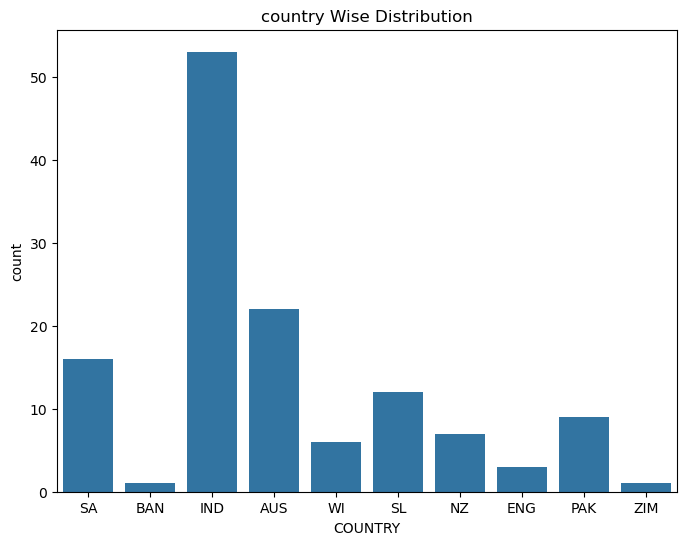

In [13]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='COUNTRY')
plt.title("country Wise Distribution")
plt.show()

- From the graph, we can observe that India has the highest number of players in the dataset.
- Australia has the second-highest number of players.
- South Africa and Sri Lanka then next Pakistan players.
- West Indies and New Zealand.
- then lats England and Zimbabwe.

In [14]:
# sns.scatterplot(data=df,x='SR-B',y='SIXERS',color='g')
# plt.title("Bating Strick vs Sixers")
# plt.show()

In [15]:
# sns.scatterplot(data=df,x='ECON',y='WKTS')
# plt.title("Economy Rate vs Wickets")
# plt.show()

In [16]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

<Axes: xlabel='BASE PRICE', ylabel='Count'>

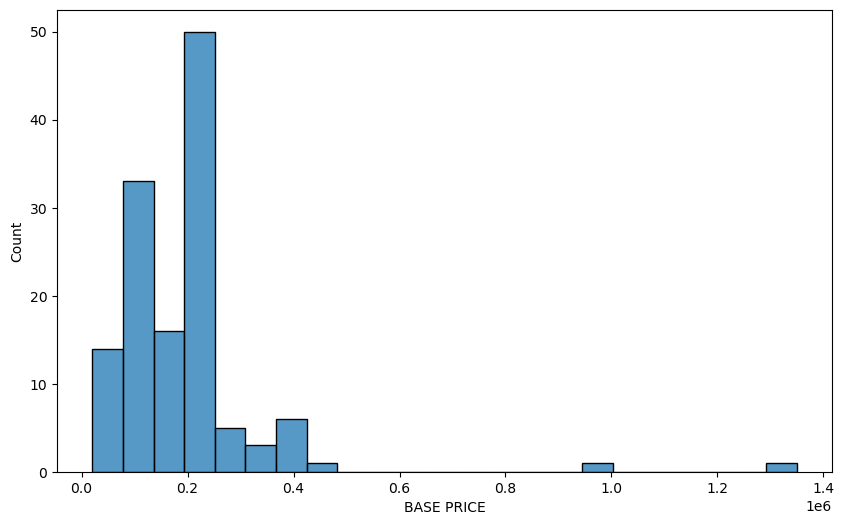

In [17]:
# sns.kdeplot(data=df,x='COUNTRY')
plt.figure(figsize=(10,6))
sns.histplot(x = 'BASE PRICE',data = df)

The highest density is above 3.5 

In [18]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

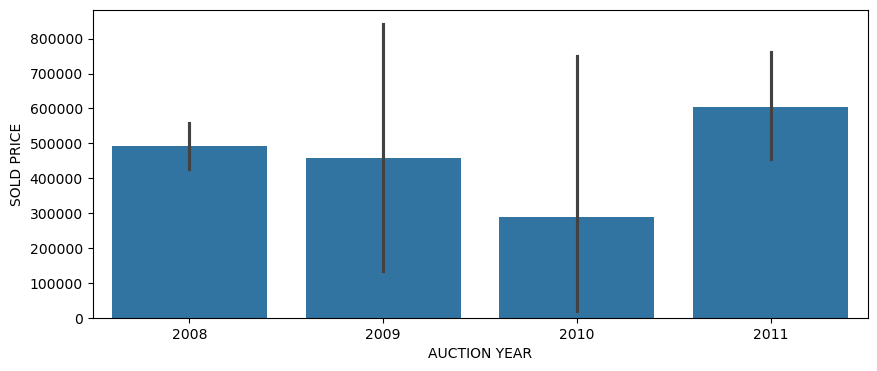

In [19]:

plt.figure(figsize =(10,4))
sns.barplot(data=df , x='AUCTION YEAR',y='SOLD PRICE')
plt.show()



- This diagram shows the sold price year-wise.
- In 2009, the sold price is higher at 800000.
- while in 2008, it is lower at 600000.

In [20]:

df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10112\514138352.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc =(1.02,1))


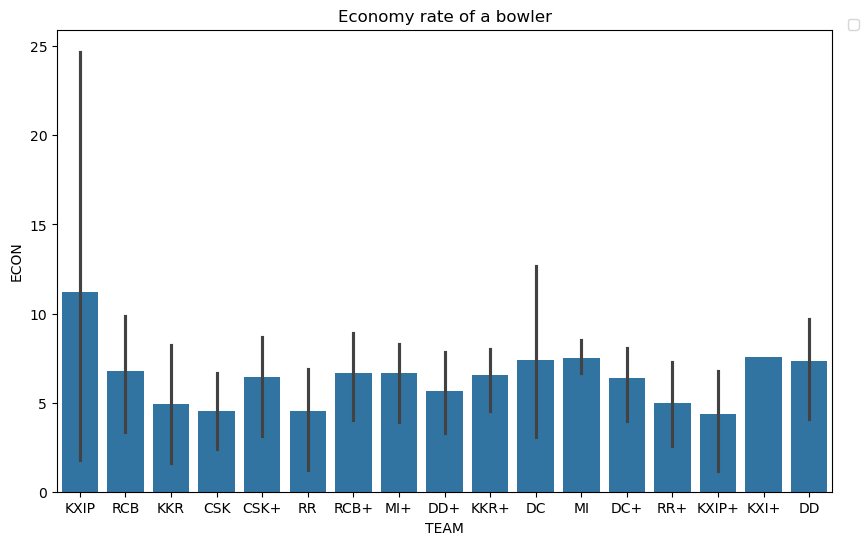

In [21]:
plt.figure(figsize =(10,6))
sns.barplot(data=df,x='TEAM',y='ECON')
plt.title("Economy rate of a bowler")
plt.legend(loc =(1.02,1))


- This diagram shows the  Economy rate of bowler 

In [22]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

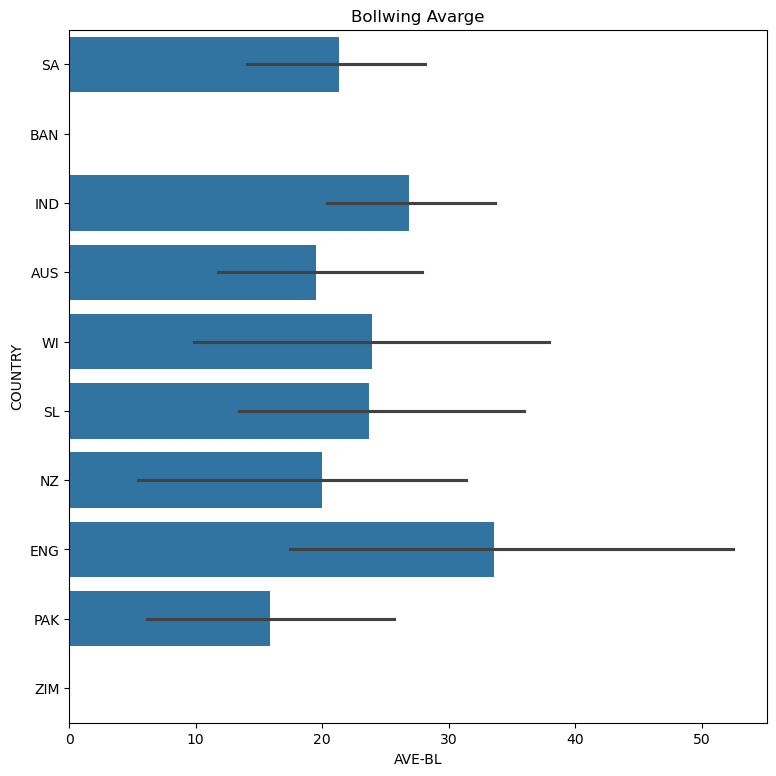

In [23]:
plt.figure(figsize=(9,9))
sns.barplot(data=df,y='COUNTRY',x='AVE-BL')
plt.title("Bollwing Avarge")
plt.show()

In this graph show in Avrage of Bowling 

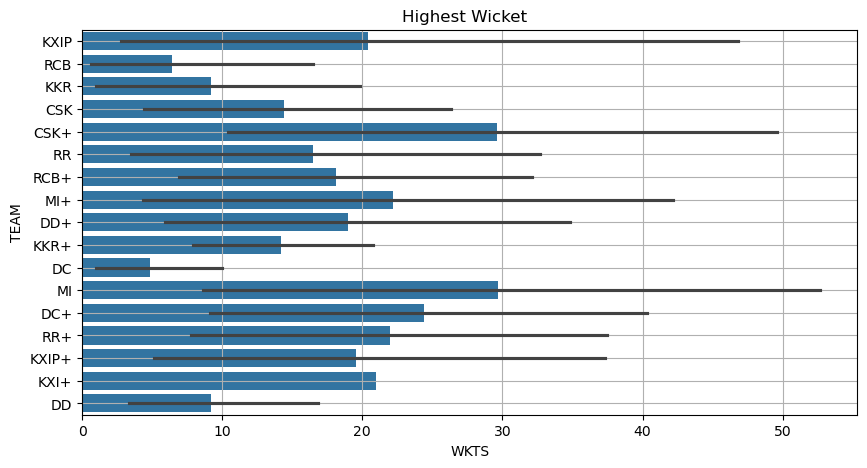

In [24]:

plt.figure(figsize=(10,5))
sns.barplot(data=df,x='WKTS',y='TEAM')
plt.title("Highest Wicket  ")
plt.grid()
plt.show()


 ## The Mumbai is highest score of wikets

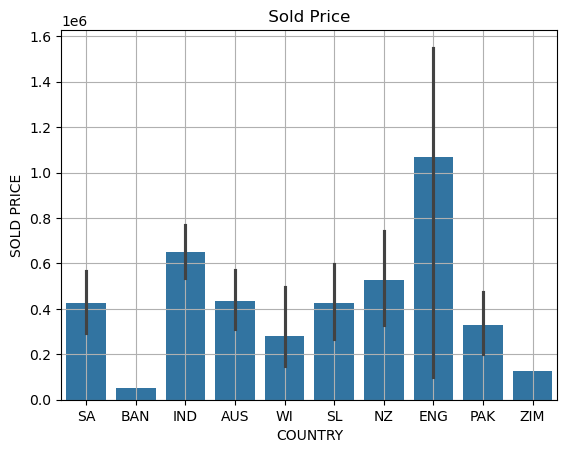

In [25]:
sns.barplot(x="COUNTRY", y="SOLD PRICE", data=df)
plt.title(" Sold Price ")
plt.grid()
plt.show()


In [26]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

Text(0.5, 1.0, ' Highest Team ')

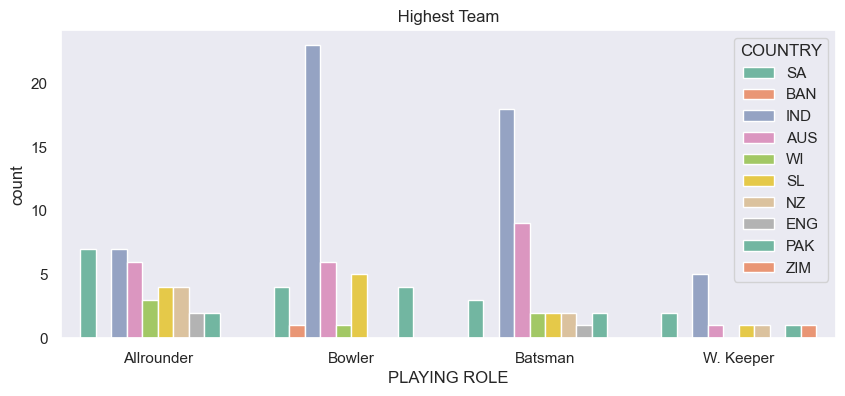

In [40]:
plt.figure(figsize = (10,4))
sns.countplot(data = df, x = 'PLAYING ROLE', hue = 'COUNTRY', palette = 'Set2')
plt.title(" Highest Team ")


### The India has highest number of players  playing roles in  IPL

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17788\1185316842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='TEAM',y='SOLD PRICE',palette='magma')


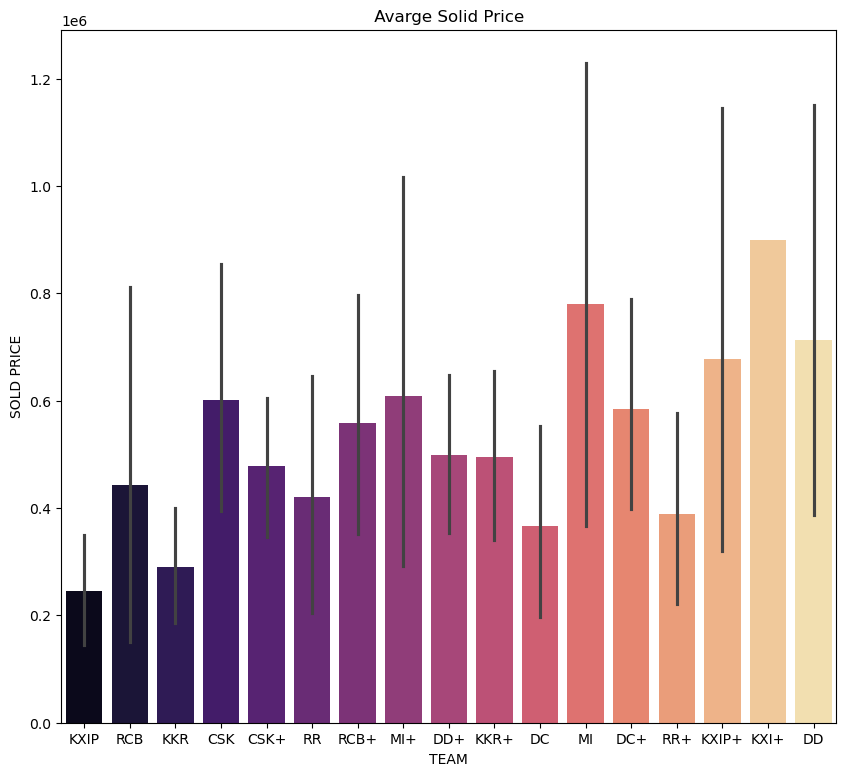

In [27]:
plt.figure(figsize=(10,9))
sns.barplot(data=df,x='TEAM',y='SOLD PRICE',palette='magma')
plt.title(" Avarge Solid Price ")
plt.show()

In [42]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

In [74]:
df.head(20)

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,0,0.0,0,0,0,0.00,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,185,37.6,0,0,0,0.00,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,288,32.9,0,167,39,18.56,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,51,36.8,0,58,11,5.80,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,0,0.0,0,1317,71,32.93,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000
5,6,"Bailey, GJ",2,AUS,CSK,Batsman,0,0,172,72.26,0,0.0,1,63,48,21.00,95.45,0,0,0,0.00,0.00,0.00,2009,50000,50000
6,7,"Balaji, L",2,IND,CSK+,Bowler,51,27,120,78.94,34,42.5,0,26,15,4.33,72.22,1,1342,52,25.81,7.98,19.40,2011,100000,500000
7,8,"Bollinger, DE",2,AUS,CSK,Bowler,54,50,50,92.59,62,31.3,0,21,16,21.00,165.88,1,693,37,18.73,7.22,15.57,2011,200000,700000
8,9,"Botha, J",2,SA,RR,Allrounder,83,17,609,85.77,72,53.0,1,335,67,30.45,114.73,3,610,19,32.11,6.85,28.11,2011,200000,950000
9,10,"Boucher, MV",2,SA,RCB+,W. Keeper,5515,1,4686,84.76,0,0.0,1,394,50,28.14,127.51,13,0,0,0.00,0.00,0.00,2008,200000,450000


In [65]:
df.sum=("SOLD PRICE")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18004\521509485.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x='TEAM',y='SOLD PRICE',style="AUCTION YEAR",palette='magma',alpha=0.9,color="g")


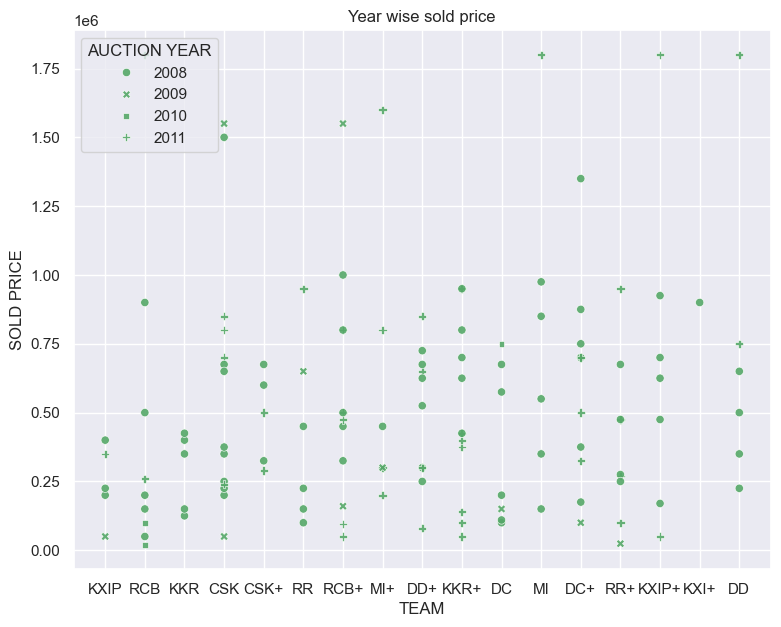

In [66]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df,x='TEAM',y='SOLD PRICE',style="AUCTION YEAR",palette='magma',alpha=0.9,color="g")
plt.grid()
plt.title("Year wise sold price")
plt.show()

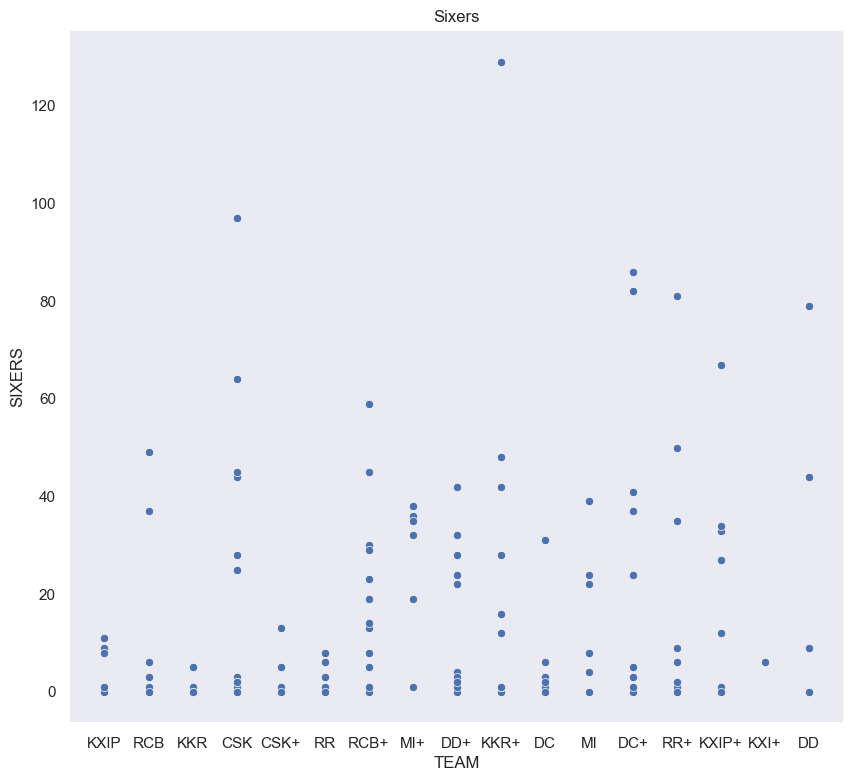

In [104]:
plt.figure(figsize=(10,9))
sns.scatterplot(data=df,x='TEAM',y='SIXERS')
plt.title("Sixers")
plt.show()

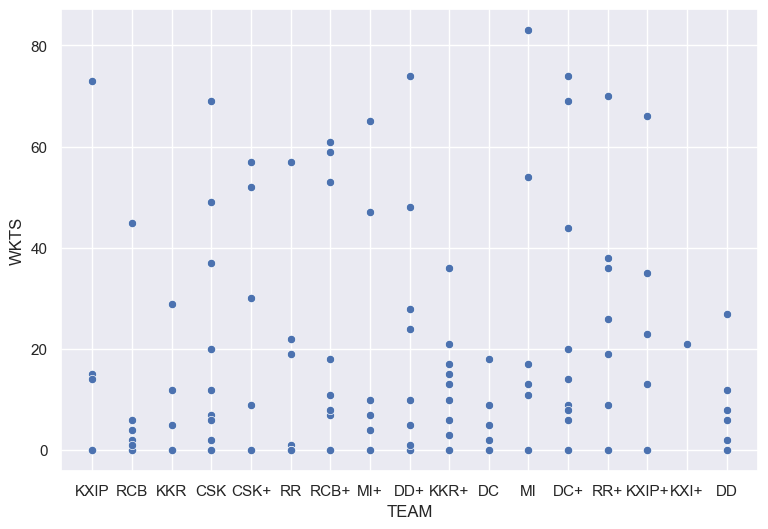

In [99]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df,x='TEAM',y='WKTS')
plt.grid()
plt.show()

- This scatter plot shows the number of wickets  by players for each IPL team.
-  Each dot represents one player.


In [105]:
df.columns


Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import pandas as pd

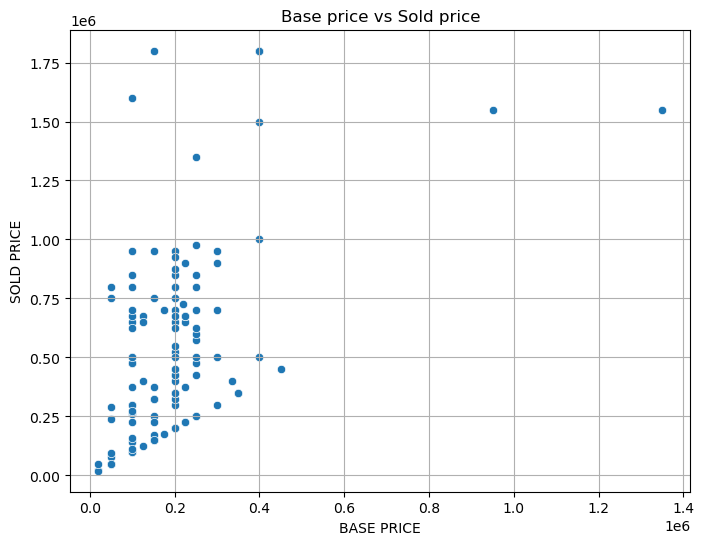

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='BASE PRICE',y='SOLD PRICE')
plt.title("Base price vs Sold price")
plt.grid()
plt.show()


- This Scatter plot shows the relationship between base price and sold price
  

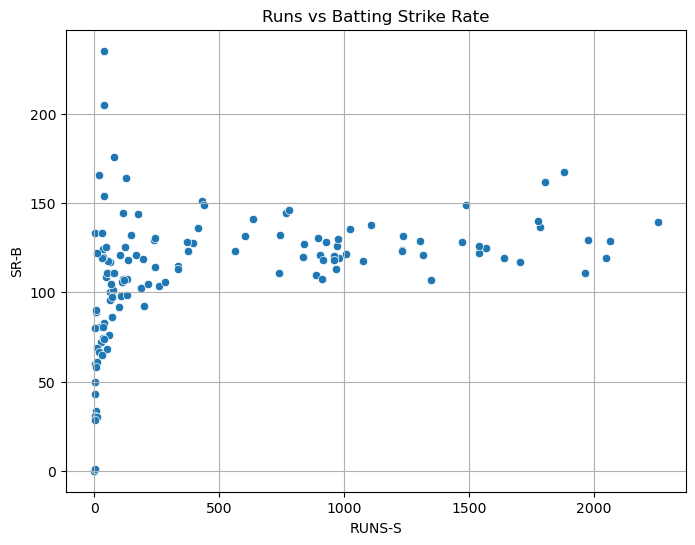

In [58]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='RUNS-S', y='SR-B')
plt.title("Runs vs Batting Strike Rate")
plt.grid()
plt.show()

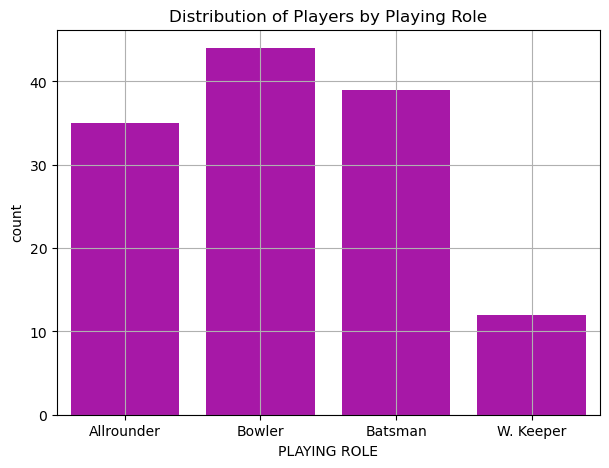

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(data=df,x='PLAYING ROLE',color='m')
plt.title("Distribution of Players by Playing Role")
plt.grid()
plt.show()


- This graphs shows in Distribution of payers based on their palying role.
- It helps Identify wether the dataset contain more bowlers,batsman,or all rounders.

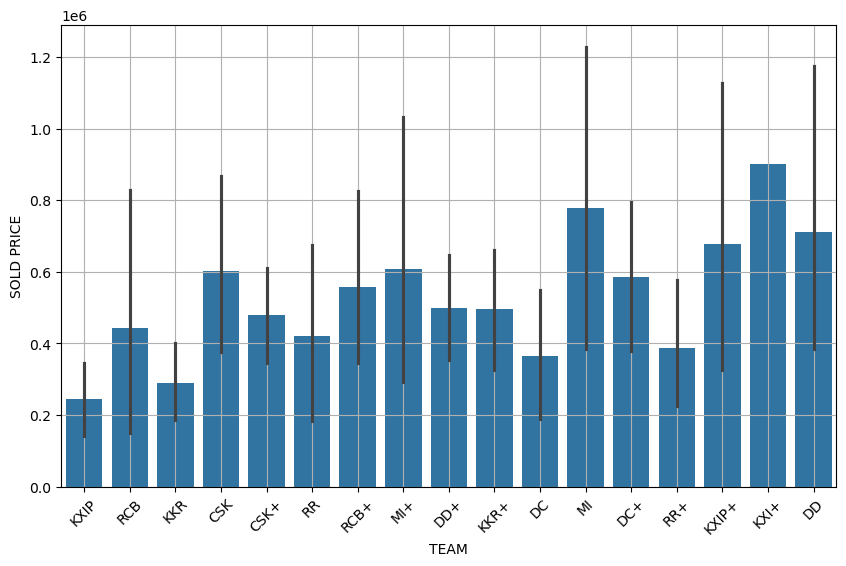

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='TEAM',y='SOLD PRICE',estimator='mean')
plt.xticks(rotation=45)
plt.grid()
plt.show()


- This graph represents the avrage action sold price for each tems.
- Tems with higher bars spend more on buying players in the action.

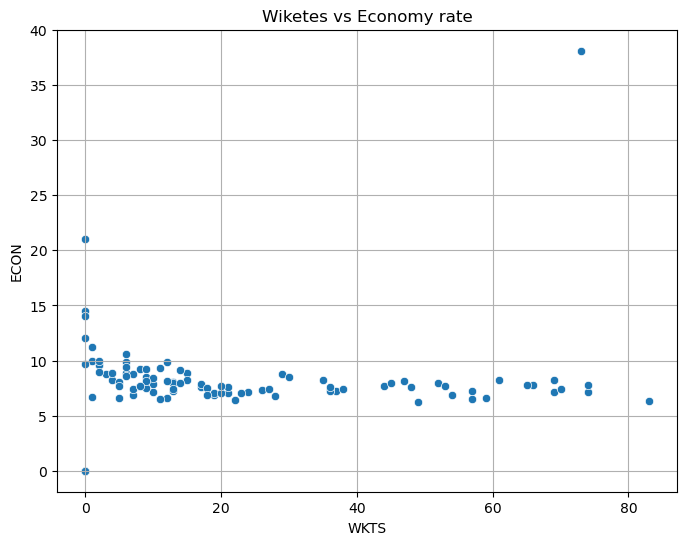

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='WKTS',y='ECON')
plt.title("Wiketes vs Economy rate")
plt.grid()
plt.show()

- This plot shows in relationship between Wickets tand Economy rate.
    

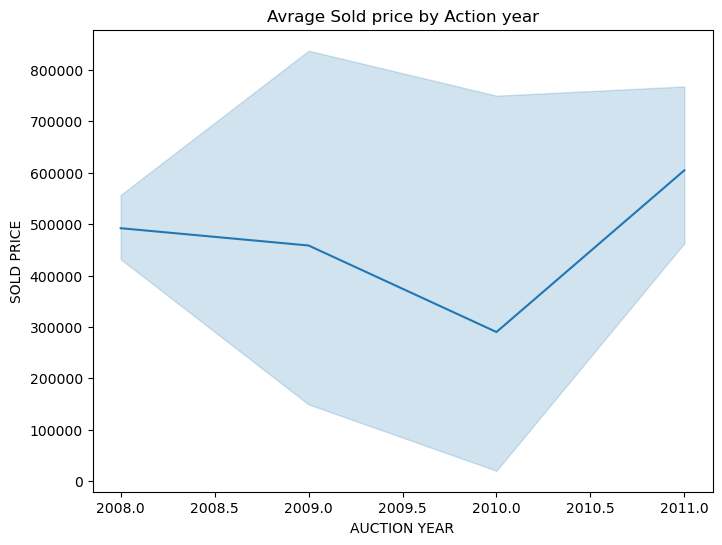

In [29]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df,x='AUCTION YEAR',y='SOLD PRICE',estimator='mean')
plt.title("Avrage Sold price by Action year")
plt.show()

- This line plot shows the avarge player prices across auction year.
- It helps observe the Wherther palyer valuation has increased over time. 

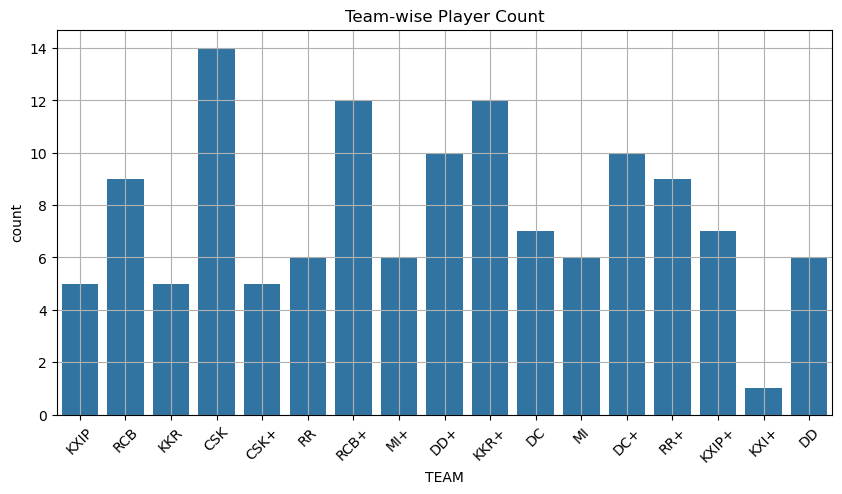

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='TEAM')
plt.title("Team-wise Player Count")
plt.xticks(rotation=45)
plt.grid()
plt.show()


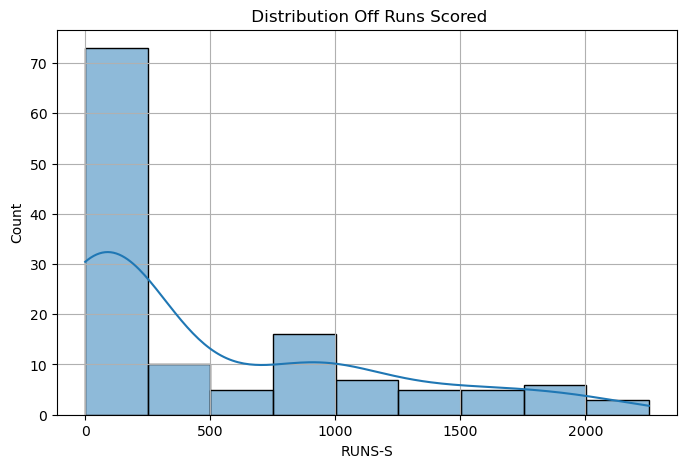

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='RUNS-S',kde=True)
plt.title(" Distribution Off Runs Scored")
plt.grid()
plt.show()

-  Disply how player batting runs of spered.

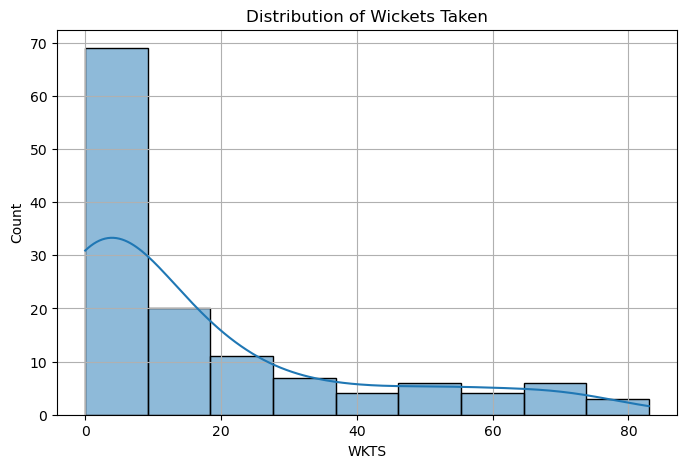

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['WKTS'], kde=True)
plt.title("Distribution of Wickets Taken")
plt.grid()
plt.show()


- show frequency of bowlers by wickets team.
  

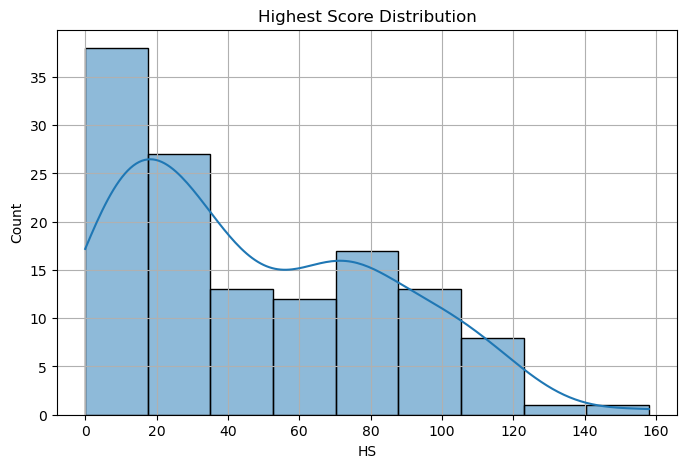

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='HS', kde=True)
plt.title("Highest Score Distribution")
plt.grid()
plt.show()


- Show  highest players score of of IPL .

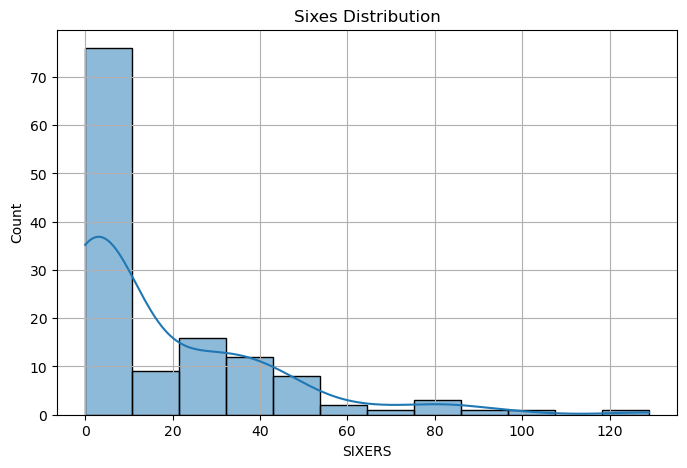

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(df['SIXERS'], kde=True)
plt.title("Sixes Distribution")
plt.grid()
plt.show()


- How many sixes palyer in IPL.

In [49]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

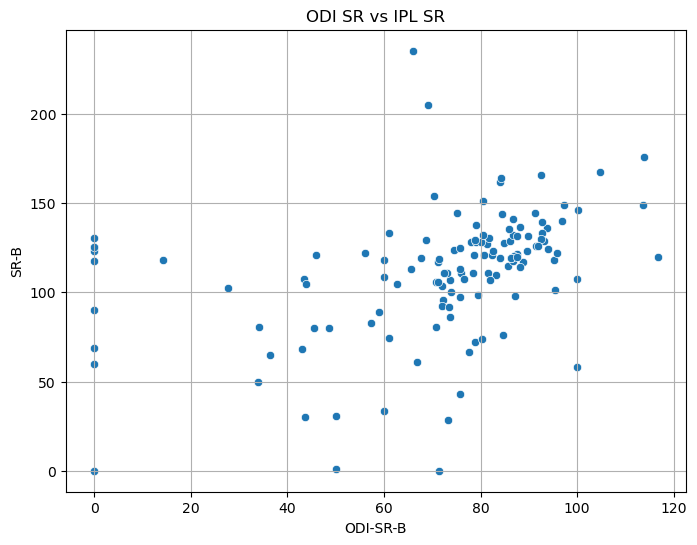

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='ODI-SR-B', y='SR-B')
plt.title("ODI SR vs IPL SR")
plt.grid()
plt.show()


- Compare Batting strick rate ODI vs IPL

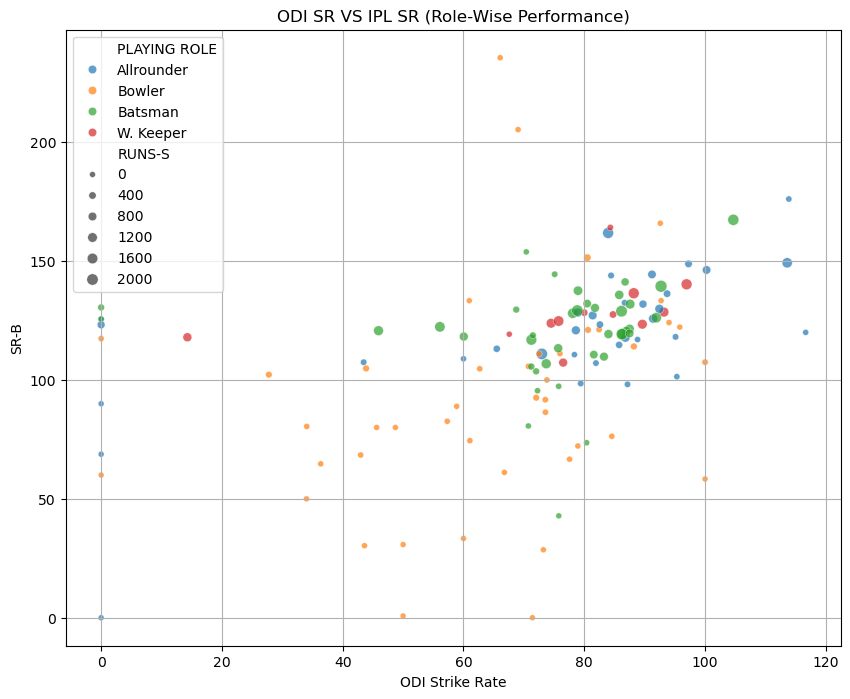

In [90]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='ODI-SR-B',y='SR-B',hue='PLAYING ROLE',size='RUNS-S',alpha=0.7)
plt.title("ODI SR VS IPL SR (Role-Wise Performance)")
plt.xlabel("ODI Strike Rate")
# Plt.ylabel("IPL Strike Rate")
plt.savefig("Graph of ODL vs IPL .png", dpi=300, bbox_inches='tight')

plt.grid(True)
plt.show()

- The coluerful scatterplot campare batting strike rate in ODI and Ipl formats.
- Dffrent color represnet palying role.
- showing  how batsman,bowlers, all-rounders perform across format.

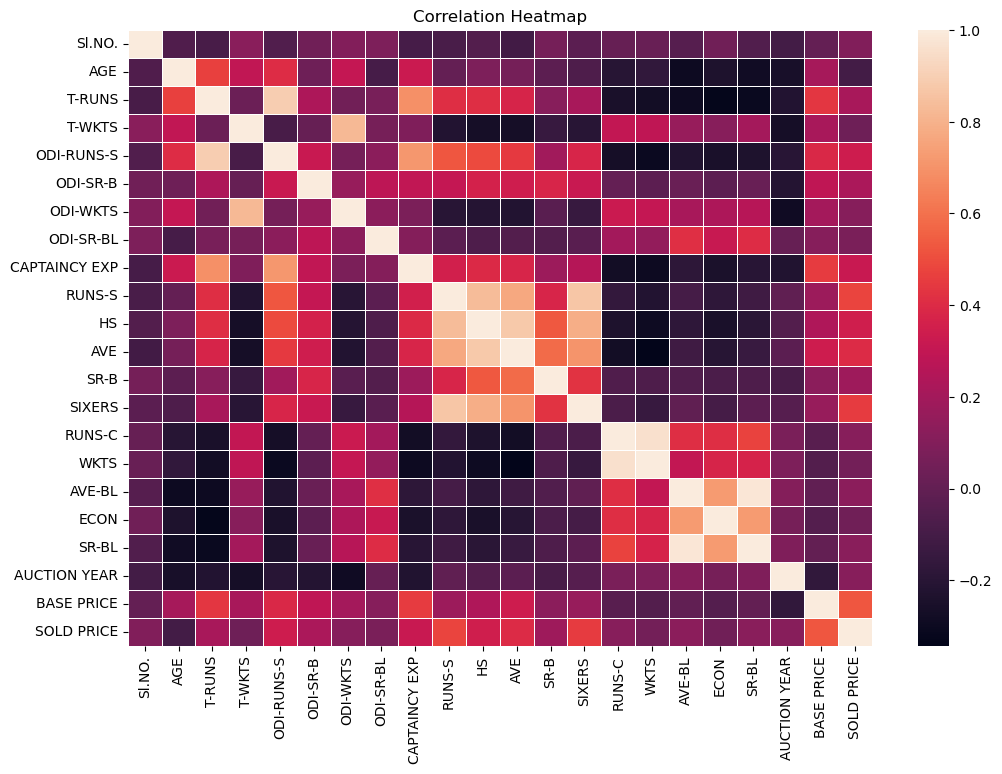

In [87]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
             linewidths=0.6)

plt.title("Correlation Heatmap")
plt.show()


- coloer contrast clarely  shows strong realationship. 

In [14]:
df.columns

Index(['Sl.NO.', 'PLAYER NAME', 'AGE', 'COUNTRY', 'TEAM', 'PLAYING ROLE',
       'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C',
       'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR', 'BASE PRICE',
       'SOLD PRICE'],
      dtype='object')

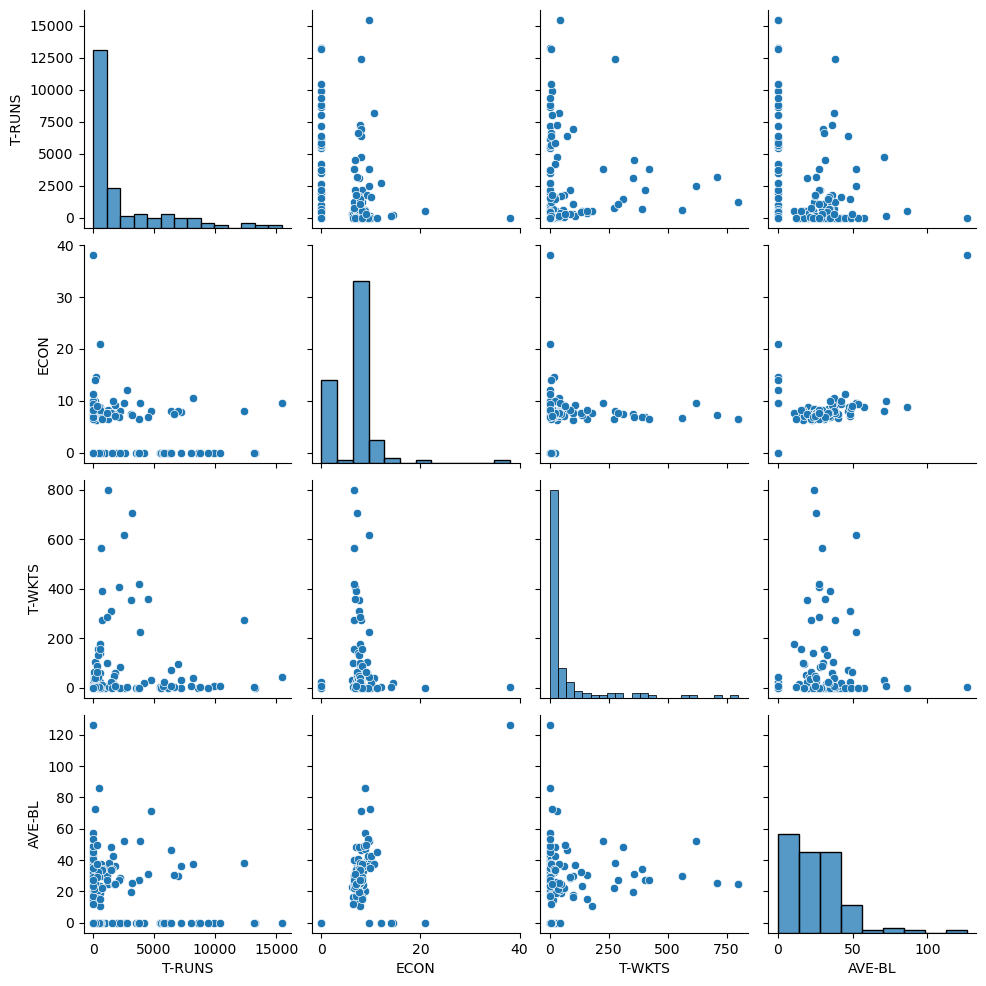

In [28]:
sns.pairplot(df[['T-RUNS','ECON','T-WKTS','AVE-BL']])
plt.show()

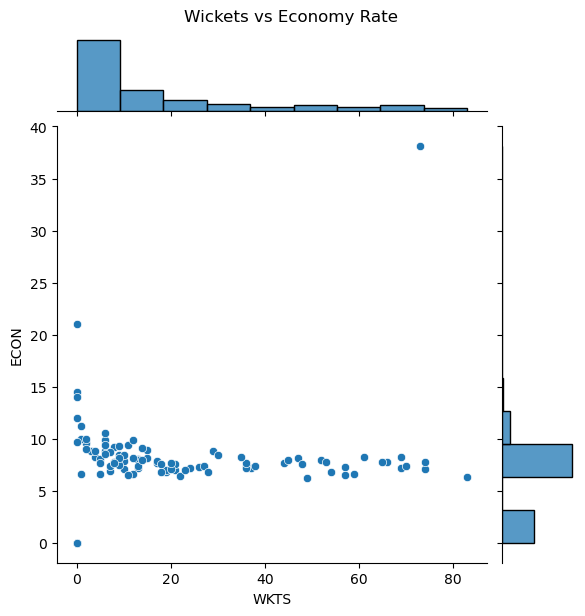

In [29]:
sns.jointplot(data=df, x="WKTS", y="ECON", kind="scatter")
plt.suptitle("Wickets vs Economy Rate", y=1.02)
plt.show()


<Figure size 1000x800 with 0 Axes>

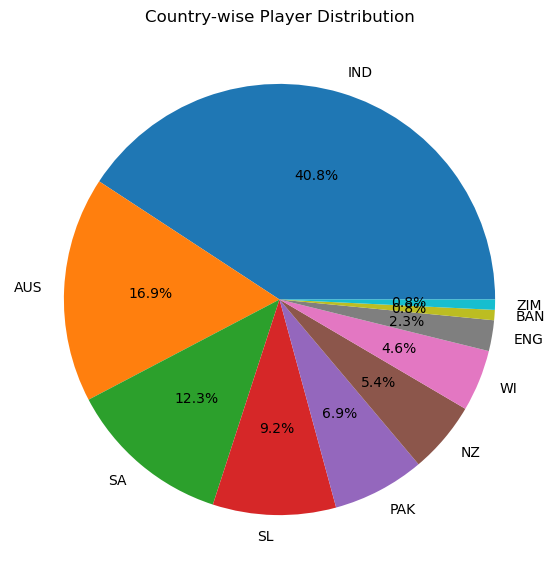

In [33]:

plt.figure(figsize=(10,8))
country_counts = df['COUNTRY'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%')
plt.title("Country-wise Player Distribution")
plt.show()





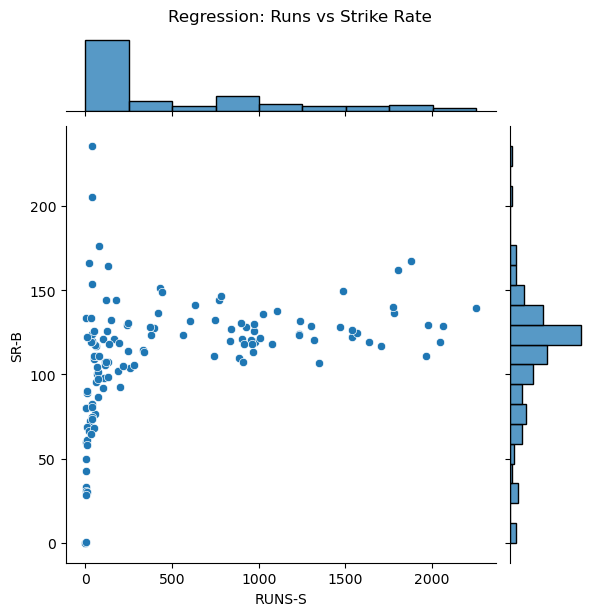

In [38]:
sns.jointplot(data=df, x="RUNS-S", y="SR-B")
plt.suptitle("Regression: Runs vs Strike Rate", y=1.02)
plt.show()
